day                    7
is_exam_day            0
weather                0
previous_day_demand    0
special_event          0
actual_demand          0
dtype: int64
Actual: 175 | Predicted: 212
Actual: 210 | Predicted: 219
Actual: 250 | Predicted: 251
Actual: 235 | Predicted: 223
Actual: 200 | Predicted: 237
Actual: 190 | Predicted: 248
Actual: 255 | Predicted: 242
Actual: 265 | Predicted: 217
Actual: 200 | Predicted: 228
Actual: 240 | Predicted: 271
Mean Absolute Error: 27.5


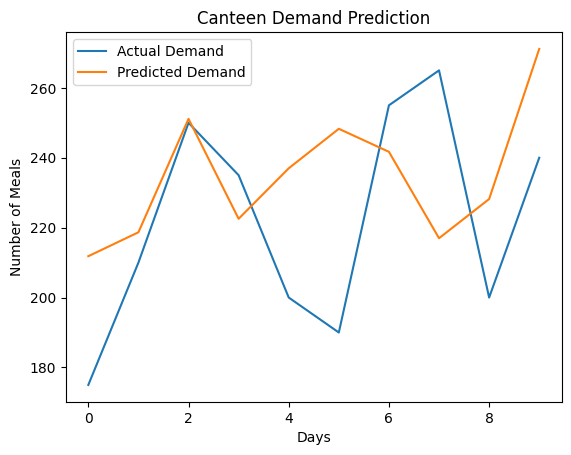

In [4]:
import pandas as pd
import matplotlib.pyplot as plt 

df = pd.read_csv("canteen_data.csv")
df

# Convert Yes/No columns
df['is_exam_day'] = df['is_exam_day'].map({'Yes': 1, 'No': 0})
df['special_event'] = df['special_event'].map({'Yes': 1, 'No': 0})

# Convert weather column
df['weather'] = df['weather'].map({
    'Hot': 2,
    'Normal': 1,
    'Rainy': 0})

# Convert day column
df['day'] = df['day'].map({
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5})

df 

# Check missing values
print(df.isna().sum())

# Fill missing values with simple defaults
df = df.fillna(0)

df


X = df[['day', 'is_exam_day', 'weather', 
'previous_day_demand', 'special_event']]
y = df["actual_demand"] 

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42) 

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) 

predictions = model.predict(X_test)
for actual, predicted in zip(y_test, predictions):
 print("Actual:", actual, "| Predicted:", round(predicted))

from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:",round(error,2))

plt.figure()
plt.plot(y_test.values, label="Actual Demand")
plt.plot(predictions, label="Predicted Demand")
plt.xlabel("Days")
plt.ylabel("Number of Meals")
plt.title("Canteen Demand Prediction")
plt.legend()
plt.show()
